# Task 15: Enterprise LLM Gateway with Dynamic Rate-Limiting & Fallback Governance

**Objective:** Design a production-style microservice gateway that sits between clients and multiple back-end LLM providers, enforcing **token-bucket rate limiting** (backed by Redis), automatic **model failover** on `5xx` errors, latency tracking, and **Prometheus** metrics export — then load-test it under simulated peak traffic.

**Stack used in this notebook:** FastAPI, Redis (real `redis-server`, with an in-memory `fakeredis` fallback), Docker/Prometheus/Grafana config generated for real deployment, `httpx` for async load generation, `prometheus_client` for metrics.

> Note on environment: FastAPI, Redis, and the load generator all run live, in-process, inside this notebook — the server actually serves real HTTP traffic on `127.0.0.1:8000`. Since notebook sandboxes can't run a Docker daemon, Section 9 generates real `Dockerfile` / `docker-compose.yml` / `prometheus.yml` files you can run with `docker-compose up` on any machine with Docker installed, to get the identical gateway fronted by Prometheus + Grafana.

**Sections**
1. Imports & configuration
2. Redis-backed token-bucket rate limiter
3. Simulated backend LLM providers (primary / secondary)
4. Prometheus metrics
5. FastAPI gateway service
6. Launching the gateway
7. Simulated peak-load test
8. Results analysis & plots
9. Live `/metrics` (Prometheus exposition format)
10. Production containerization (Docker Compose + Prometheus + Grafana)
11. Shutdown


In [1]:

import time
import json
import random
import asyncio
import threading
from dataclasses import dataclass

import httpx
import uvicorn
from fastapi import FastAPI, HTTPException, Response
from pydantic import BaseModel
from prometheus_client import Counter, Histogram, Gauge, CONTENT_TYPE_LATEST, generate_latest

import pandas as pd
import matplotlib.pyplot as plt

random.seed(42)

# --- Simulated failure profile for the two backend providers ---
PRIMARY_FAILURE_RATE   = 0.35   # primary is flaky -> forces failovers
SECONDARY_FAILURE_RATE = 0.05   # secondary is the reliable fallback

# --- Token bucket rate limit config ---
RATE_LIMIT_CAPACITY    = 15     # max burst tokens per client
RATE_LIMIT_REFILL_RATE = 3.0    # tokens refilled per second

GATEWAY_HOST = "127.0.0.1"
GATEWAY_PORT = 8000
GATEWAY_URL  = f"http://{GATEWAY_HOST}:{GATEWAY_PORT}"

print("Config loaded.")


Config loaded.


## 2. Redis-backed token-bucket rate limiter

A classic **token bucket**: each client key holds `tokens` (current balance) and `ts` (last refill timestamp) in a Redis hash. On every request we atomically refill based on elapsed time, then attempt to spend one token. Atomicity is enforced with a **Lua script executed via `EVAL`**, so concurrent requests from the same client can't race past the limiter.

The notebook first tries to connect to a real local `redis-server` (started via `redis-server --daemonize yes` in this environment). If Redis isn't reachable, it transparently falls back to `fakeredis` (in-memory, same API) so the notebook still runs anywhere.


In [2]:
import redis as redis_lib

try:
    redis_client = redis_lib.Redis(host="localhost", port=6379, decode_responses=True,
                                    socket_connect_timeout=1)
    redis_client.ping()
    REDIS_BACKEND = "real redis-server (localhost:6379)"
except Exception as e:
    import fakeredis
    redis_client = fakeredis.FakeStrictRedis(decode_responses=True)
    REDIS_BACKEND = f"in-memory fakeredis (real Redis unavailable: {e})"

print("Rate limiter backing store:", REDIS_BACKEND)

TOKEN_BUCKET_LUA = """
local key = KEYS[1]
local capacity = tonumber(ARGV[1])
local refill_rate = tonumber(ARGV[2])
local now = tonumber(ARGV[3])
local requested = tonumber(ARGV[4])

local bucket = redis.call('HMGET', key, 'tokens', 'ts')
local tokens = tonumber(bucket[1])
local ts = tonumber(bucket[2])

if tokens == nil then
    tokens = capacity
    ts = now
end

local elapsed = now - ts
if elapsed < 0 then elapsed = 0 end
tokens = math.min(capacity, tokens + elapsed * refill_rate)

local allowed = 0
if tokens >= requested then
    tokens = tokens - requested
    allowed = 1
end

redis.call('HMSET', key, 'tokens', tokens, 'ts', now)
redis.call('EXPIRE', key, 3600)

return {allowed, tostring(tokens)}
"""

class TokenBucketRateLimiter:
    """Redis-backed, Lua-atomic token bucket rate limiter (per client_id)."""

    def __init__(self, client, capacity: float, refill_rate: float):
        self.client = client
        self.capacity = capacity
        self.refill_rate = refill_rate
        try:
            self.script = self.client.register_script(TOKEN_BUCKET_LUA)
            self.use_lua = True
        except Exception:
            # fakeredis without lua support (no lupa) -> pure-python fallback
            self.use_lua = False
            self._lock = threading.Lock()

    def allow(self, client_id: str, cost: float = 1.0):
        key = f"ratelimit:{client_id}"
        now = time.time()
        if self.use_lua:
            allowed, remaining = self.script(keys=[key], args=[self.capacity, self.refill_rate, now, cost])
            return bool(int(allowed)), float(remaining)
        # Fallback: non-atomic but lock-protected, single-process only
        with self._lock:
            tokens, ts = self.client.hmget(key, "tokens", "ts")
            tokens = float(tokens) if tokens is not None else self.capacity
            ts = float(ts) if ts is not None else now
            tokens = min(self.capacity, tokens + max(0.0, now - ts) * self.refill_rate)
            allowed = tokens >= cost
            if allowed:
                tokens -= cost
            self.client.hmset(key, {"tokens": tokens, "ts": now})
            self.client.expire(key, 3600)
            return allowed, tokens

rate_limiter = TokenBucketRateLimiter(redis_client, RATE_LIMIT_CAPACITY, RATE_LIMIT_REFILL_RATE)

# quick sanity check
ok, remaining = rate_limiter.allow("sanity_check_client")
print(f"Sanity check -> allowed={ok}, tokens_remaining={remaining:.2f}")


Rate limiter backing store: real redis-server (localhost:6379)
Sanity check -> allowed=True, tokens_remaining=14.00


## 3. Simulated backend LLM providers

Two async "providers" stand in for real model endpoints (e.g. a primary self-hosted model and a secondary hosted API). Each has independent latency and failure characteristics; the primary is deliberately flaky (`35%` error rate) so the gateway's failover logic gets exercised during the load test.


In [3]:

class BackendUnavailable(Exception):
    def __init__(self, status_code: int):
        self.status_code = status_code
        super().__init__(f"backend returned {status_code}")

async def call_primary_llm(prompt: str) -> dict:
    await asyncio.sleep(random.uniform(0.04, 0.20))
    if random.random() < PRIMARY_FAILURE_RATE:
        raise BackendUnavailable(random.choice([500, 502, 503]))
    return {"provider": "primary", "text": f"[primary-model] {prompt[:60]}"}

async def call_secondary_llm(prompt: str) -> dict:
    await asyncio.sleep(random.uniform(0.07, 0.30))
    if random.random() < SECONDARY_FAILURE_RATE:
        raise BackendUnavailable(random.choice([500, 503]))
    return {"provider": "secondary", "text": f"[secondary-model] {prompt[:60]}"}

print(f"Primary failure rate:   {PRIMARY_FAILURE_RATE:.0%}")
print(f"Secondary failure rate: {SECONDARY_FAILURE_RATE:.0%}")


Primary failure rate:   35%
Secondary failure rate: 5%


## 4. Prometheus metrics

Structural performance metrics exported in native Prometheus exposition format via `prometheus_client`, ready for a real Prometheus server to scrape and Grafana to visualize.


In [4]:

REQUEST_COUNT = Counter(
    "gateway_requests_total", "Total requests received by the gateway", ["client_id"]
)
RATE_LIMITED_COUNT = Counter(
    "gateway_rate_limited_total", "Requests rejected by the rate limiter", ["client_id"]
)
FAILOVER_COUNT = Counter(
    "gateway_failover_total", "Requests that failed over from primary to secondary"
)
PROVIDER_ERROR_COUNT = Counter(
    "gateway_provider_errors_total", "Backend provider errors", ["provider"]
)
REQUEST_LATENCY = Histogram(
    "gateway_request_latency_seconds", "End-to-end gateway latency", ["provider"]
)
IN_FLIGHT = Gauge(
    "gateway_in_flight_requests", "Requests currently being processed"
)

print("Prometheus metrics registered.")


Prometheus metrics registered.


## 5. FastAPI gateway service

`POST /v1/chat/completions` — rate-limits by `client_id`, calls the primary provider, and **automatically fails over to the secondary provider on any `5xx`**. `GET /metrics` exposes Prometheus metrics; `GET /health` is a liveness probe (used for both this notebook and a container orchestrator's healthcheck).


In [5]:

app = FastAPI(title="Enterprise LLM Gateway", version="1.0.0")

class ChatRequest(BaseModel):
    client_id: str
    prompt: str

@app.post("/v1/chat/completions")
async def chat_completions(req: ChatRequest):
    REQUEST_COUNT.labels(client_id=req.client_id).inc()
    IN_FLIGHT.inc()
    start = time.time()
    try:
        allowed, remaining = rate_limiter.allow(req.client_id)
        if not allowed:
            RATE_LIMITED_COUNT.labels(client_id=req.client_id).inc()
            raise HTTPException(
                status_code=429,
                detail=f"Rate limit exceeded for '{req.client_id}'. Tokens remaining: {remaining:.2f}",
            )

        provider_used = "primary"
        try:
            result = await call_primary_llm(req.prompt)
        except BackendUnavailable:
            PROVIDER_ERROR_COUNT.labels(provider="primary").inc()
            FAILOVER_COUNT.inc()
            provider_used = "secondary"
            try:
                result = await call_secondary_llm(req.prompt)
            except BackendUnavailable:
                PROVIDER_ERROR_COUNT.labels(provider="secondary").inc()
                raise HTTPException(
                    status_code=503,
                    detail="Both primary and secondary providers are unavailable",
                )

        elapsed = time.time() - start
        REQUEST_LATENCY.labels(provider=provider_used).observe(elapsed)
        return {**result, "latency_ms": round(elapsed * 1000, 2), "client_id": req.client_id}
    finally:
        IN_FLIGHT.dec()

@app.get("/metrics")
def metrics():
    return Response(generate_latest(), media_type=CONTENT_TYPE_LATEST)

@app.get("/health")
def health():
    return {"status": "ok"}

print("FastAPI app defined: POST /v1/chat/completions, GET /metrics, GET /health")


FastAPI app defined: POST /v1/chat/completions, GET /metrics, GET /health


## 6. Launching the gateway

Runs `uvicorn` in a background thread inside the notebook process, so it accepts real HTTP connections on `127.0.0.1:8000` for the rest of this notebook.


In [6]:

uv_config = uvicorn.Config(app, host=GATEWAY_HOST, port=GATEWAY_PORT, log_level="warning")
uv_server = uvicorn.Server(uv_config)

def _run_server():
    uv_server.run()

server_thread = threading.Thread(target=_run_server, daemon=True)
server_thread.start()

for _ in range(100):
    try:
        r = httpx.get(f"{GATEWAY_URL}/health", timeout=1)
        if r.status_code == 200:
            print("Gateway is live:", r.json(), "at", GATEWAY_URL)
            break
    except Exception:
        time.sleep(0.1)
else:
    raise RuntimeError("Gateway did not start in time")


Gateway is live: {'status': 'ok'} at http://127.0.0.1:8000


## 7. Simulated peak-load test

5 concurrent clients each fire 40 requests (200 total) at the gateway with no throttling on the client side — a burst well above each client's token-bucket capacity (`15` tokens, refilling at `3`/sec) — to exercise rate limiting, and against a primary provider with a `35%` failure rate to exercise failover.


In [7]:

CLIENTS = [f"client_{i}" for i in range(5)]
REQUESTS_PER_CLIENT = 40

async def send_request(client: httpx.AsyncClient, client_id: str, seq: int):
    prompt = f"Request #{seq} from {client_id}"
    t0 = time.time()
    try:
        resp = await client.post(
            f"{GATEWAY_URL}/v1/chat/completions",
            json={"client_id": client_id, "prompt": prompt},
            timeout=5,
        )
        latency = time.time() - t0
        provider = resp.json().get("provider") if resp.status_code == 200 else None
        return {"client_id": client_id, "seq": seq, "status": resp.status_code,
                "latency": latency, "provider": provider}
    except Exception as e:
        return {"client_id": client_id, "seq": seq, "status": -1,
                "latency": time.time() - t0, "provider": None, "error": str(e)}

async def run_load_test():
    limits = httpx.Limits(max_connections=250, max_keepalive_connections=250)
    async with httpx.AsyncClient(limits=limits) as client:
        tasks = [
            send_request(client, cid, seq)
            for seq in range(REQUESTS_PER_CLIENT)
            for cid in CLIENTS
        ]
        return await asyncio.gather(*tasks)

t_start = time.time()
results = await run_load_test()
total_wall_time = time.time() - t_start

print(f"Fired {len(results)} requests across {len(CLIENTS)} clients in {total_wall_time:.2f}s "
      f"({len(results)/total_wall_time:.1f} req/s)")


Fired 200 requests across 5 clients in 1.09s (183.1 req/s)


## 8. Results analysis & plots

In [8]:

df = pd.DataFrame(results)

print("Status code breakdown:")
print(df["status"].value_counts().sort_index().to_string())
print()
print("Successful-request latency (ms) by provider:")
print((df[df.status == 200].groupby("provider")["latency"].describe() * 1000).round(2)
      [["count", "mean", "std", "min", "50%", "max"]]
      .rename(columns={"count": "count_raw"}).assign(count=lambda d: (d["count_raw"]/1000).round(0))
      .drop(columns="count_raw"))


Status code breakdown:
status
200     74
429    125
503      1

Successful-request latency (ms) by provider:
             mean    std     min     50%      max  count
provider                                                
primary    783.05  59.86  663.69  784.19   895.63   45.0
secondary  952.57  48.34  842.70  949.99  1051.95   29.0


In [9]:

n_ok          = (df.status == 200).sum()
n_rate_limited = (df.status == 429).sum()
n_failovers   = (df[df.status == 200]["provider"] == "secondary").sum()
n_hard_fail   = (df.status == 503).sum()

print(f"Total requests sent:        {len(df)}")
print(f"  Succeeded (200):          {n_ok}")
print(f"  Rate-limited (429):       {n_rate_limited}")
print(f"  Failed over to secondary: {n_failovers}  ({n_failovers/max(n_ok,1):.1%} of successes)")
print(f"  Both providers down (503):{n_hard_fail}")


Total requests sent:        200
  Succeeded (200):          74
  Rate-limited (429):       125
  Failed over to secondary: 29  (39.2% of successes)
  Both providers down (503):1


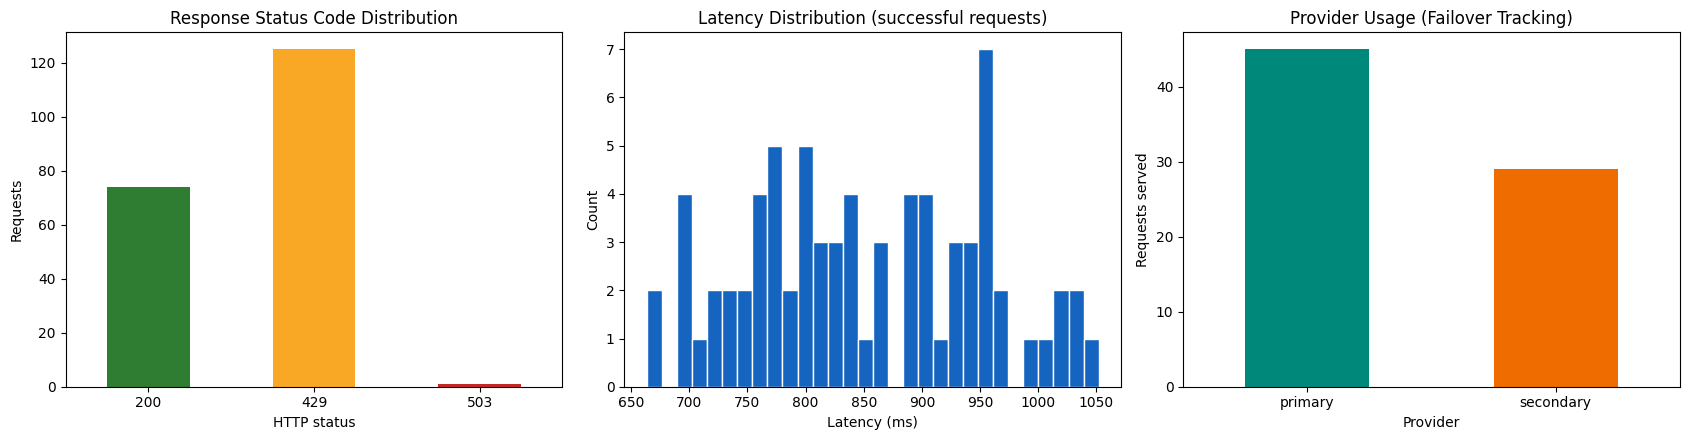

In [10]:

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

status_counts = df["status"].value_counts().sort_index()
colors = {200: "#2e7d32", 429: "#f9a825", 503: "#c62828", -1: "#616161"}
status_counts.plot(kind="bar", ax=axes[0],
                    color=[colors.get(s, "#1976d2") for s in status_counts.index])
axes[0].set_title("Response Status Code Distribution")
axes[0].set_xlabel("HTTP status")
axes[0].set_ylabel("Requests")
axes[0].tick_params(axis="x", rotation=0)

ok_latency_ms = df[df.status == 200]["latency"] * 1000
axes[1].hist(ok_latency_ms, bins=30, color="#1565c0", edgecolor="white")
axes[1].set_title("Latency Distribution (successful requests)")
axes[1].set_xlabel("Latency (ms)")
axes[1].set_ylabel("Count")

provider_counts = df[df.status == 200]["provider"].value_counts()
provider_counts.plot(kind="bar", ax=axes[2], color=["#00897b", "#ef6c00"])
axes[2].set_title("Provider Usage (Failover Tracking)")
axes[2].set_xlabel("Provider")
axes[2].set_ylabel("Requests served")
axes[2].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig("gateway_load_test_results.png", dpi=110)
plt.show()


## 9. Live `/metrics` endpoint

This is the exact Prometheus exposition-format text a real Prometheus server would scrape from this gateway at `GET /metrics`.


In [11]:

metrics_resp = httpx.get(f"{GATEWAY_URL}/metrics")
lines = [l for l in metrics_resp.text.splitlines() if l.startswith("gateway_")]
print("\n".join(lines))


gateway_requests_total{client_id="client_0"} 40.0
gateway_requests_total{client_id="client_1"} 40.0
gateway_requests_total{client_id="client_2"} 40.0
gateway_requests_total{client_id="client_3"} 40.0
gateway_requests_total{client_id="client_4"} 40.0
gateway_requests_created{client_id="client_0"} 1.7862967461824653e+09
gateway_requests_created{client_id="client_1"} 1.7862967461830277e+09
gateway_requests_created{client_id="client_2"} 1.7862967461833572e+09
gateway_requests_created{client_id="client_3"} 1.7862967461836016e+09
gateway_requests_created{client_id="client_4"} 1.7862967461838703e+09
gateway_rate_limited_total{client_id="client_0"} 25.0
gateway_rate_limited_total{client_id="client_1"} 25.0
gateway_rate_limited_total{client_id="client_3"} 25.0
gateway_rate_limited_total{client_id="client_4"} 25.0
gateway_rate_limited_total{client_id="client_2"} 25.0
gateway_rate_limited_created{client_id="client_0"} 1.7862967462045038e+09
gateway_rate_limited_created{client_id="client_1"} 1.786

## 10. Production containerization: Docker Compose + Prometheus + Grafana

The gateway logic above is deployment-ready as-is. Below are the actual `Dockerfile`, `docker-compose.yml`, and `prometheus.yml` needed to run the **same FastAPI app** as a containerized microservice, fronted by a real Redis container, scraped by Prometheus, and visualized in Grafana.

Running Docker containers isn't possible inside this notebook sandbox, so these files are generated to disk here — copy this folder anywhere Docker is installed and run `docker-compose up -d`.


In [12]:
import os
os.makedirs("deploy", exist_ok=True)

TOKEN_BUCKET_LUA_SRC = (
    'local key = KEYS[1]\n'
    'local capacity = tonumber(ARGV[1])\n'
    'local refill_rate = tonumber(ARGV[2])\n'
    'local now = tonumber(ARGV[3])\n'
    'local requested = tonumber(ARGV[4])\n'
    'local bucket = redis.call("HMGET", key, "tokens", "ts")\n'
    'local tokens = tonumber(bucket[1])\n'
    'local ts = tonumber(bucket[2])\n'
    'if tokens == nil then tokens = capacity ts = now end\n'
    'local elapsed = now - ts\n'
    'if elapsed < 0 then elapsed = 0 end\n'
    'tokens = math.min(capacity, tokens + elapsed * refill_rate)\n'
    'local allowed = 0\n'
    'if tokens >= requested then tokens = tokens - requested allowed = 1 end\n'
    'redis.call("HMSET", key, "tokens", tokens, "ts", now)\n'
    'redis.call("EXPIRE", key, 3600)\n'
    'return {allowed, tostring(tokens)}'
)

# 1) Standalone gateway module (same logic as the in-notebook FastAPI app above),
#    written out as a real deployable file that talks to a "redis" container by hostname.
gateway_py = '''import time, random, asyncio
from fastapi import FastAPI, HTTPException, Response
from pydantic import BaseModel
from prometheus_client import Counter, Histogram, Gauge, CONTENT_TYPE_LATEST, generate_latest
import redis

RATE_LIMIT_CAPACITY = 15
RATE_LIMIT_REFILL_RATE = 3.0
PRIMARY_FAILURE_RATE = 0.35
SECONDARY_FAILURE_RATE = 0.05

redis_client = redis.Redis(host="redis", port=6379, decode_responses=True)

TOKEN_BUCKET_LUA = """__LUA_PLACEHOLDER__"""
script = redis_client.register_script(TOKEN_BUCKET_LUA)

def allow(client_id, cost=1.0):
    now = time.time()
    allowed, remaining = script(keys=[f"ratelimit:{client_id}"],
                                 args=[RATE_LIMIT_CAPACITY, RATE_LIMIT_REFILL_RATE, now, cost])
    return bool(int(allowed)), float(remaining)

class BackendUnavailable(Exception):
    def __init__(self, code):
        self.status_code = code

async def call_primary_llm(prompt):
    await asyncio.sleep(random.uniform(0.04, 0.20))
    if random.random() < PRIMARY_FAILURE_RATE:
        raise BackendUnavailable(random.choice([500, 502, 503]))
    return {"provider": "primary", "text": f"[primary-model] {prompt[:60]}"}

async def call_secondary_llm(prompt):
    await asyncio.sleep(random.uniform(0.07, 0.30))
    if random.random() < SECONDARY_FAILURE_RATE:
        raise BackendUnavailable(random.choice([500, 503]))
    return {"provider": "secondary", "text": f"[secondary-model] {prompt[:60]}"}

REQUEST_COUNT = Counter("gateway_requests_total", "Total requests", ["client_id"])
RATE_LIMITED_COUNT = Counter("gateway_rate_limited_total", "Rate limited requests", ["client_id"])
FAILOVER_COUNT = Counter("gateway_failover_total", "Failovers to secondary")
PROVIDER_ERROR_COUNT = Counter("gateway_provider_errors_total", "Provider errors", ["provider"])
REQUEST_LATENCY = Histogram("gateway_request_latency_seconds", "Gateway latency", ["provider"])
IN_FLIGHT = Gauge("gateway_in_flight_requests", "In-flight requests")

app = FastAPI(title="Enterprise LLM Gateway")

class ChatRequest(BaseModel):
    client_id: str
    prompt: str

@app.post("/v1/chat/completions")
async def chat_completions(req: ChatRequest):
    REQUEST_COUNT.labels(client_id=req.client_id).inc()
    IN_FLIGHT.inc()
    start = time.time()
    try:
        allowed, remaining = allow(req.client_id)
        if not allowed:
            RATE_LIMITED_COUNT.labels(client_id=req.client_id).inc()
            raise HTTPException(429, f"Rate limit exceeded. Tokens remaining: {remaining:.2f}")
        provider_used = "primary"
        try:
            result = await call_primary_llm(req.prompt)
        except BackendUnavailable:
            PROVIDER_ERROR_COUNT.labels(provider="primary").inc()
            FAILOVER_COUNT.inc()
            provider_used = "secondary"
            try:
                result = await call_secondary_llm(req.prompt)
            except BackendUnavailable:
                PROVIDER_ERROR_COUNT.labels(provider="secondary").inc()
                raise HTTPException(503, "Both providers unavailable")
        elapsed = time.time() - start
        REQUEST_LATENCY.labels(provider=provider_used).observe(elapsed)
        return {**result, "latency_ms": round(elapsed * 1000, 2), "client_id": req.client_id}
    finally:
        IN_FLIGHT.dec()

@app.get("/metrics")
def metrics():
    return Response(generate_latest(), media_type=CONTENT_TYPE_LATEST)

@app.get("/health")
def health():
    return {"status": "ok"}
'''

gateway_py = gateway_py.replace("__LUA_PLACEHOLDER__", TOKEN_BUCKET_LUA_SRC)

with open("deploy/gateway.py", "w") as f:
    f.write(gateway_py)

dockerfile = '''FROM python:3.11-slim
WORKDIR /app
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt
COPY gateway.py .
EXPOSE 8000
CMD ["uvicorn", "gateway:app", "--host", "0.0.0.0", "--port", "8000"]
'''
with open("deploy/Dockerfile", "w") as f:
    f.write(dockerfile)

requirements_txt = "fastapi\nuvicorn[standard]\nredis\nprometheus_client\npydantic\n"
with open("deploy/requirements.txt", "w") as f:
    f.write(requirements_txt)

docker_compose_yml = '''version: "3.9"

services:
  redis:
    image: redis:7-alpine
    ports:
      - "6379:6379"
    healthcheck:
      test: ["CMD", "redis-cli", "ping"]
      interval: 5s
      timeout: 3s
      retries: 5

  gateway:
    build: .
    ports:
      - "8000:8000"
    depends_on:
      redis:
        condition: service_healthy
    healthcheck:
      test: ["CMD", "python", "-c", "import urllib.request; urllib.request.urlopen('http://localhost:8000/health')"]
      interval: 10s
      timeout: 3s
      retries: 5
    deploy:
      replicas: 2
      restart_policy:
        condition: on-failure

  prometheus:
    image: prom/prometheus:latest
    ports:
      - "9090:9090"
    volumes:
      - ./prometheus.yml:/etc/prometheus/prometheus.yml
    depends_on:
      - gateway

  grafana:
    image: grafana/grafana:latest
    ports:
      - "3000:3000"
    environment:
      - GF_SECURITY_ADMIN_PASSWORD=admin
    depends_on:
      - prometheus
'''
with open("deploy/docker-compose.yml", "w") as f:
    f.write(docker_compose_yml)

prometheus_yml = '''global:
  scrape_interval: 5s

scrape_configs:
  - job_name: "llm-gateway"
    static_configs:
      - targets: ["gateway:8000"]
'''
with open("deploy/prometheus.yml", "w") as f:
    f.write(prometheus_yml)

print("Wrote deploy/gateway.py, Dockerfile, requirements.txt, docker-compose.yml, prometheus.yml")
print("\nTo run for real:")
print("  cd deploy && docker-compose up -d --scale gateway=2")
print("  Gateway:    http://localhost:8000")
print("  Prometheus: http://localhost:9090")
print("  Grafana:    http://localhost:3000  (admin/admin)")


Wrote deploy/gateway.py, Dockerfile, requirements.txt, docker-compose.yml, prometheus.yml

To run for real:
  cd deploy && docker-compose up -d --scale gateway=2
  Gateway:    http://localhost:8000
  Prometheus: http://localhost:9090
  Grafana:    http://localhost:3000  (admin/admin)


## 11. Shutdown

In [13]:

uv_server.should_exit = True
server_thread.join(timeout=5)
print("Gateway server stopped." if not server_thread.is_alive() else "Gateway still shutting down...")


Gateway server stopped.
